In [2]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# Build Hamiltonian

In [3]:
spin_dim = 9/2
Ix = qt.jmat(spin_dim,'x')
Iy = qt.jmat(spin_dim,'y')
Iz = qt.jmat(spin_dim,'z')
Iz2 = Iz*Iz
Ix2 = Ix*Ix

# Electron spin-1/2 operators (2x2 matrices)
Sx = qt.jmat(1/2, 'x')
Sy = qt.jmat(1/2, 'y')
Sz = qt.jmat(1/2, 'z')

In [4]:
# unknown quadrupole
def calculate_H_quad(V_ab):
    # V_ab = np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]])*1e19
    I_vec = [Ix, Iy, Iz]
    q_n = -0.69e-28
    e = 1.6e-19
    h = 6.626e-34
    I = 7/2
    Q_ab = e*q_n*V_ab/(2*I*(2*I-1))/h

    H_quad = 0
    for alpha in [0, 1, 2]:
        for beta in [0, 1, 2]:
            H_quad += Q_ab[alpha, beta] * I_vec[alpha] * I_vec[beta]

    H_quad = qt.Qobj(H_quad) / 1e6 # all defined in MHz
    return H_quad

V_ab = np.array([[ 2.66386380e+19,  7.68297638e+19, -6.56105323e+18],
       [ 7.68297638e+19, -7.72005988e+18, -1.30014550e+19],
       [-6.56105323e+18, -1.30014550e+19, -1.89185782e+19]])
H_quad = calculate_H_quad(V_ab)

In [11]:
H_nuclear = 1.48 * Iz  # Nuclear Zeeman term
H_electron = 28.8e3 * Sz  # Electron Zeeman term

A = 0.3
H_hyperfine = A * (qt.tensor(Sx, Ix) + qt.tensor(Sy, Iy) + qt.tensor(Sz, Iz))

H0_ionized = 1 * H_nuclear
H0_neutral = 1 * (qt.tensor(H_electron, qt.qeye(10)) + qt.tensor(qt.qeye(2), H_nuclear))

H_ionized = - H0_ionized + 1*qt.Qobj(H_quad)
H_neutral = - H0_neutral - H_hyperfine + 1*qt.tensor(qt.qeye(2), qt.Qobj(H_quad))
H_neutral = qt.Qobj(H_neutral.full())

In [12]:
P_donor = qt.tensor(qt.Qobj(np.array([[1, 0], [0, 1], [0, 0]])), qt.qeye(10))
P_SET = qt.tensor(qt.Qobj(np.array([0, 0, 1])), qt.qeye(10))

H_neutral_full = qt.Qobj(P_donor.full() @ H_neutral.full() @ P_donor.dag().full())
H_ionized_full = qt.Qobj(P_SET.full() @ H_ionized.full() @ P_SET.dag().full())
H_full = H_neutral_full + H_ionized_full

In [13]:
P_donor.full() @ H_neutral.full() @ P_donor.dag().full()

array([[-1.44071999e+04+0.j        ,  3.12336802e-02-0.061893j  ,
        -4.08908655e-02+0.18287279j,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ,
         0.00000000e+00+0.j        ,  0.00000000e+00+0.j        ],
       [ 

Text(0.5, 1.0, 'Neutral + Ionized')

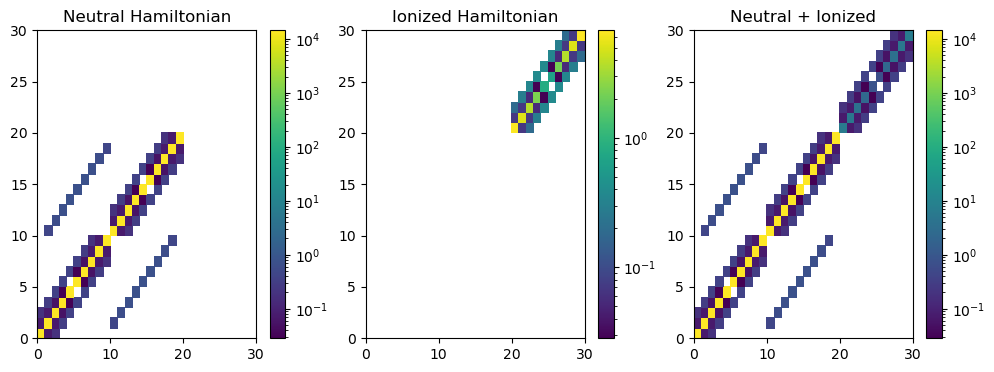

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
pcm1 = ax[0].pcolor(np.abs(H_neutral_full.full()), norm=LogNorm())
pcm2 = ax[1].pcolor(np.abs(H_ionized_full.full()), norm=LogNorm())
pcm3 = ax[2].pcolor(np.abs(H_full.full()), norm=LogNorm())
plt.colorbar(pcm1, ax=ax[0])
plt.colorbar(pcm2, ax=ax[1])
plt.colorbar(pcm3, ax=ax[2])
ax[0].set_title('Neutral Hamiltonian')
ax[1].set_title('Ionized Hamiltonian')
ax[2].set_title('Neutral + Ionized')

In [15]:
(eigenvalues_full, eigenstates_full) = H_full.eigenstates()
eigenstate_full_matrix = np.zeros([3*10,3*10], dtype=complex)
for i in range(30):
    idx_argmax = np.argmax(np.abs(eigenstates_full[i].full().flatten())**2)
    eigenstate_full_matrix[idx_argmax] = eigenstates_full[i].full().flatten()

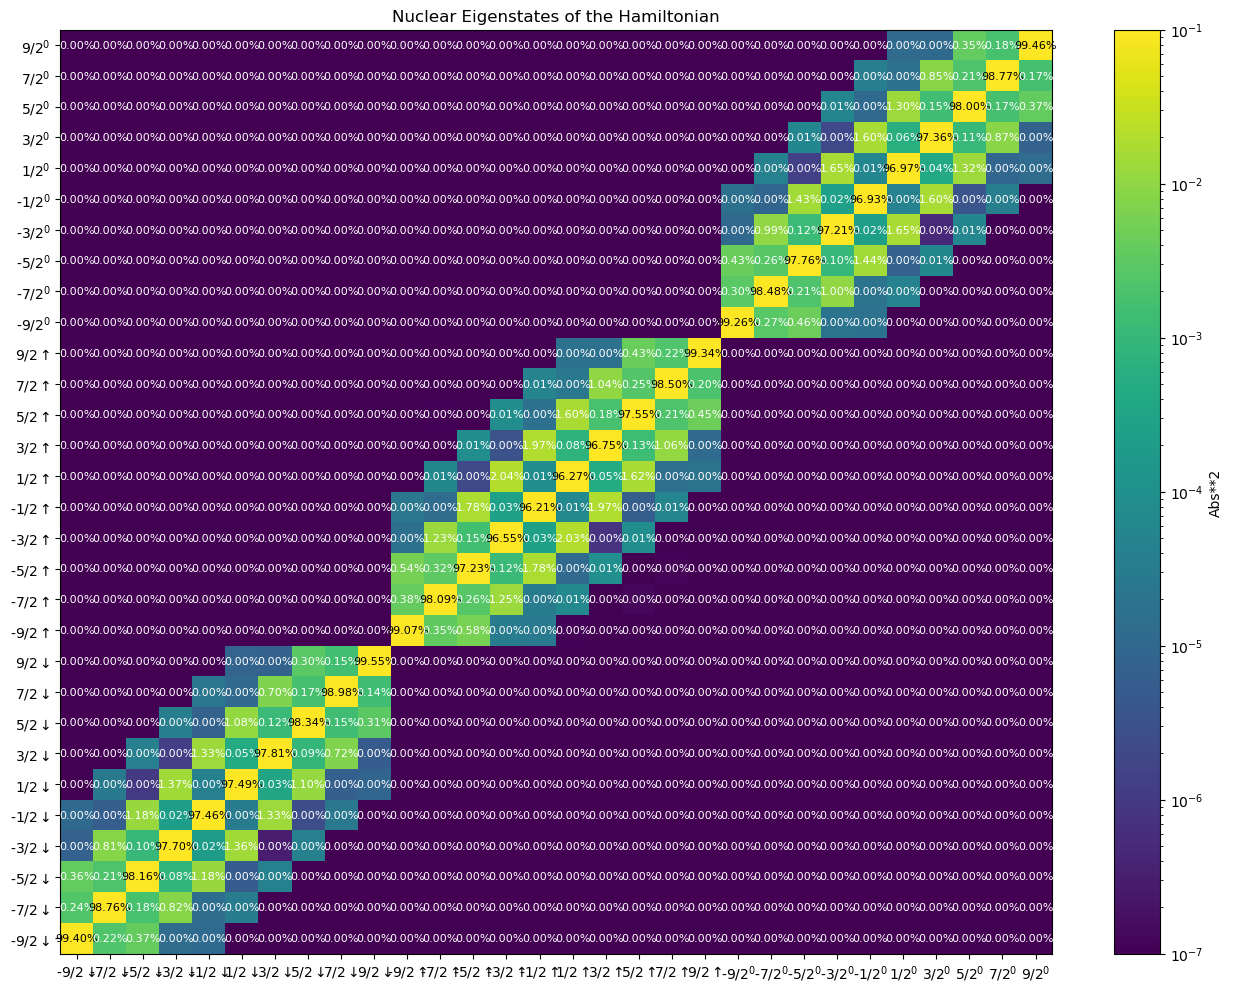

In [16]:
import matplotlib.colors as mcolors
fig, ax = plt.subplots(1,1, figsize=(16,12))
Z = np.abs(eigenstate_full_matrix)**2
X, Y = np.arange(30), np.arange(30)
# Plot with pcolormesh using LogNorm
Z[Z==0]=1e-7

# Convert to percentage
Z_percent = Z * 100  
pcm = plt.pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")

nucleus_labels = ["-9/2", "-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2", "9/2"]
electron_labels = [r"$\downarrow$", r"$\uparrow$", r"$^0$"]

ax.set_xticks(np.arange(3*10))
ax.set_yticks(np.arange(3*10))
ax.set_xticklabels([nucleus_labels[k%10] + electron_labels[(k//10)] for k in range(30)])
ax.set_yticklabels([nucleus_labels[k%10] + electron_labels[(k//10)] for k in range(30)])

# Annotate with percentages
for i in range(30):
    for j in range(30):
        color = 'black' if i == j else 'white'  # Diagonal elements in black
        ax.text(j, i, f"{Z_percent[i, j]:.2f}%", 
                ha='center', va='center', fontsize=8, color=color)

ax.set_title('Nuclear Eigenstates of the Hamiltonian')

plt.colorbar(label='Abs**2')

In [17]:
eigenstate_full_matrix[1]

array([ 4.89110134e-02+0.00000000e+00j,  5.20067751e-01+8.46808051e-01j,
        2.35931090e-02-3.48509440e-02j, -6.55038644e-02+6.28384487e-02j,
        3.38986015e-03+1.31390529e-03j, -4.52031751e-03-3.00157646e-03j,
       -2.43598517e-05+1.50772968e-04j,  6.91615976e-05-1.82170860e-04j,
       -2.63161860e-06+9.14593082e-08j,  2.74057690e-06+3.82998481e-07j,
        8.12611328e-06+1.32314652e-05j,  4.91523353e-07-7.26071780e-07j,
       -1.56336785e-06+1.49975147e-06j,  8.64951907e-08+3.35252239e-08j,
       -1.17718477e-07-7.81673841e-08j, -6.21606168e-10+3.84742960e-09j,
        1.65095211e-09-4.34857986e-09j, -5.48470617e-11+1.90666497e-12j,
        4.28517568e-11+5.98865787e-12j, -5.63466352e-17-2.46871210e-16j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000

In [18]:
eigenstate_full_matrix[:, 1]

array([-2.29815913e-02-4.09681973e-02j,  5.20067751e-01+8.46808051e-01j,
        4.39745389e-02+1.31280024e-02j, -4.02087287e-02-8.05170741e-02j,
       -2.38890691e-03-3.83370190e-04j,  1.71858706e-03+4.94232543e-03j,
        1.99069907e-05-1.18260252e-05j, -1.77688431e-04-1.78899853e-05j,
       -2.34903191e-06-7.43253565e-07j,  9.38470543e-07+2.17112479e-06j,
       -8.78447691e-06-1.28336990e-05j, -9.14448836e-07-3.19827174e-07j,
       -5.57018684e-07-1.00723691e-06j,  6.03061657e-08+1.43897010e-08j,
       -2.88161088e-08-7.06228516e-08j,  1.91294887e-09+1.50661160e-10j,
        2.56536487e-10+3.48549672e-09j,  3.75194049e-12+1.19190388e-11j,
        4.63233581e-11+7.27278467e-11j,  1.27733727e-12+2.30143709e-13j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        0.00000000e+00+0.00000000e+00j,  0.00000000

# Lindblad simulation

## ionization

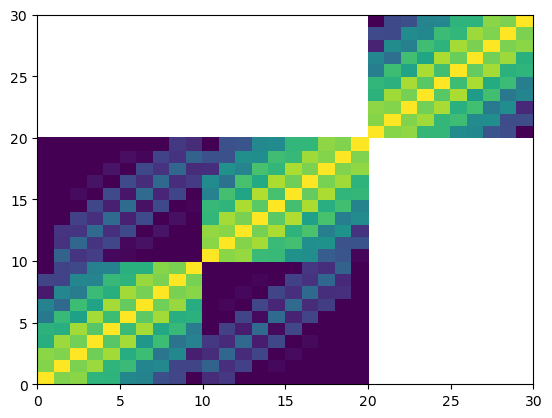

In [19]:
plt.pcolor(np.abs(eigenstate_full_matrix), norm=LogNorm(vmin=1e-7, vmax=1), cmap="viridis")

In [20]:
d=10

def find_ionization_op(gamma_out):
    """
    Generate ionization Lindblad operators for a given eigenstate matrix and ionization rate.

    This function calculates the Lindblad operators that describe the ionization process,
    where transitions occur from neutral states to ionized states. The operators are
    constructed based on the eigenstate matrix and the ionization rate.

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_out : float
        The ionization rate, which determines the strength of the ionization process.

    Returns:
    --------
    ionization_ops : numpy.ndarray
        A 4D array of shape (d, d, 24, 24) containing the ionization Lindblad operators.
        Each operator corresponds to a specific transition between neutral and ionized states.
    """
    ionization_op = np.zeros((3*d, 3*d), dtype=complex)

    set_ket = qt.tensor(qt.basis(3, 2), qt.qeye(d))
    up_bra = qt.tensor(qt.basis(3, 1), qt.qeye(d)).dag()
    ionization_op = np.sqrt(gamma_out) * set_ket * up_bra
    
    return ionization_op.full()

def find_neutralizing_op(gamma_in):
    """
    Generate neutralizing Lindblad operators for a given eigenstate matrix and neutralization rate.

    This function calculates the Lindblad operators that describe the neutralization process,
    where transitions occur from ionized states to neutral states. The operators are
    constructed based on the eigenstate matrix and the neutralization rate.

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_in : float
        The neutralization rate, which determines the strength of the neutralization process.

    Returns:
    --------
    neutralizing_ops : numpy.ndarray
        A 4D array of shape (8, 8, 24, 24) containing the neutralization Lindblad operators.
        Each operator corresponds to a specific transition between ionized and neutral states.
    """
    neutralizing_op = np.zeros((3*d, 3*d), dtype=complex)
    set_bra = qt.tensor(qt.basis(3, 2), qt.qeye(d)).dag()
    down_ket = qt.tensor(qt.basis(3, 0), qt.qeye(d))
    neutralizing_op = np.sqrt(gamma_in) * down_ket * set_bra

    return neutralizing_op.full()

def find_neutralizing_op_spin_up(gamma_in_up):
    """
    Generate neutralizing Lindblad operators for a given eigenstate matrix and neutralization rate.

    This function calculates the Lindblad operators that describe the neutralization process,
    where transitions occur from ionized states to neutral states. The operators are
    constructed based on the eigenstate matrix and the neutralization rate.

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_in : float
        The neutralization rate, which determines the strength of the neutralization process.

    Returns:
    --------
    neutralizing_ops : numpy.ndarray
        A 4D array of shape (8, 8, 24, 24) containing the neutralization Lindblad operators.
        Each operator corresponds to a specific transition between ionized and neutral states.
    """
    neutralizing_op = np.zeros((3*d, 3*d), dtype=complex)
    set_bra = qt.tensor(qt.basis(3, 2), qt.qeye(d)).dag()
    up_ket = qt.tensor(qt.basis(3, 0), qt.qeye(d))
    neutralizing_op = np.sqrt(gamma_in_up) * up_ket * set_bra

    return neutralizing_op.full()

def find_flip_flop_op(gamma_flip_flop):
    """
    Generate Lindblad operators for flip-flop relaxation processes.

    Parameters:
    -----------
    eigenstate_full_matrix : numpy.ndarray
        A 2D array where each column represents an eigenstate of the system in the full basis.
    gamma_flip_flop : float
        The rate of the flip-flop relaxation process.

    Returns:
    --------
    flip_flop_ops : list of Qobj
        A list of Lindblad operators describing the flip-flop relaxation processes.
    """
    flip_flop_op = np.zeros((d, 3*d, 3*d), dtype=complex)
    up_bra = qt.tensor(qt.basis(3, 1), qt.Qobj(np.eye(d, d, -1))).dag()
    down_ket = qt.tensor(qt.basis(3, 0), qt.Qobj(np.eye(d, d, 0)))
    flip_flop_op = np.sqrt(gamma_flip_flop) * down_ket * up_bra

    return flip_flop_op.full()

def find_ionized_measurement_op(gamma_meas):
    """
    Generate the ionized measurement operator.

    This function constructs the measurement operator for the ionized state, which is used to
    determine the state of the system after a measurement process.

    Returns:
    --------
    ionized_measurement_op : numpy.ndarray
        A 2D array representing the ionized measurement operator.
    """
    ionized_measurement_ops = np.zeros((d, 3*d, 3*d), dtype=complex)
    for i in range(d):
        ionized_measurement_ops[i] = np.sqrt(gamma_meas) * eigenstate_full_matrix[2*d+i].reshape(-1, 1) @ eigenstate_full_matrix[2*d+i].reshape(-1, 1).T.conj()

    return ionized_measurement_ops

In [30]:
gamma_out = 1/1e-6
gamma_in = 1/1e-6
gamma_ff = 1/1e-6
# Generate the Lindblad operators for ionization and neutralization processes

ff_ops = find_flip_flop_op(gamma_ff)
ion_meas_ops = find_ionized_measurement_op(gamma_out)

In [31]:
neutralizing_op = find_neutralizing_op(gamma_in)

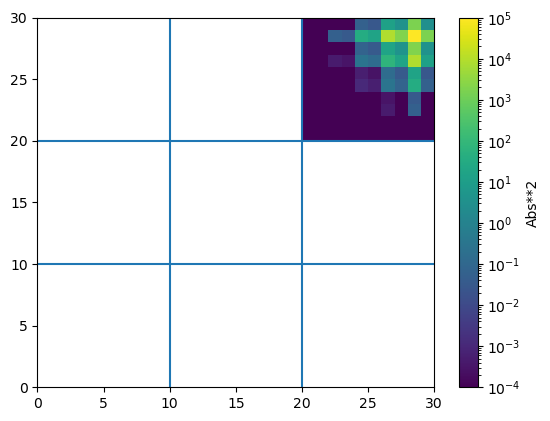

In [32]:
# example of an ionization operator, that ionizes from |5/2, up> to |5/2, SET>
plt.pcolormesh(np.abs(ion_meas_ops[8])**2, norm=mcolors.LogNorm(vmin=1e-4, vmax=100000), cmap="viridis")
plt.colorbar(label='Abs**2')
plt.axvline(d)
plt.axhline(d)
plt.axvline(2*d)
plt.axhline(2*d)

# Generalize ionization shock

In [33]:

# def compute_ionization_shock(rho_0, eigenstate_full_matrix, H_full, gamma_out, gamma_in, gamma_ff, t_list):
def compute_ionization_shock_simple(rho_0, H_full, gamma_out, gamma_in, gamma_ff, t_list):
    """
    Compute the ionization shock for a given initial state using simplified operators.

    Parameters:
    -----------
    rho_0 : Qobj
        The initial density matrix of the system.
    H_full : Qobj
        The full Hamiltonian of the system.
    gamma_out : float
        The ionization rate.
    gamma_in : float
        The neutralization rate.
    gamma_ff : float
        The flip-flop rate.
    t_list : numpy.ndarray
        The time points for the evolution.

    Returns:
    --------
    result : dict
        A dictionary containing the final states after ionization, measurement, and neutralization.
    """

    # Generate ionization, neutralizing, and flip-flop operators
    ionization_op = find_ionization_op(gamma_out)
    neutralizing_op = find_neutralizing_op(gamma_in)
    flip_flop_op = find_flip_flop_op(gamma_ff)
    
    # Perform ionization with ionization and flip-flop operators
    jump_ops_ionization = [qt.Qobj(ionization_op), qt.Qobj(flip_flop_op)]
    result_ionization = qt.mesolve(H_full, rho_0, t_list, c_ops=jump_ops_ionization, e_ops=[], args={}, options=None)
    ionized_state = result_ionization.states[-1]

    # Perform measurement on the ionized state
    measure_ionized_op = find_ionized_measurement_op(gamma_out)
    jump_ops_measure = [qt.Qobj(measure_ionized_op[i]) for i in range(d)]
    result_measured = qt.mesolve(H_full, ionized_state, t_list, c_ops=jump_ops_measure)
    measured_state = result_measured.states[-1]

    # Perform neutralization with neutralizing and flip-flop operators
    result_neutralization = qt.mesolve(H_full, measured_state, t_list, c_ops=[qt.Qobj(neutralizing_op), qt.Qobj(flip_flop_op)])
    neutralized_state = result_neutralization.states[-1]

    # Return results
    return {
        "ionized_state": ionized_state,
        "measured_state": measured_state,
        "neutralized_state": neutralized_state,
    }


# def compute_ionization_shock(rho_0, eigenstate_full_matrix, H_full, gamma_out, gamma_in, gamma_ff, t_list):
def compute_ionization_shock_simple_with_error(rho_0, H_full, gamma_out, gamma_in, gamma_ff, t_list):
    """
    Compute the ionization shock for a given initial state using simplified operators.

    Parameters:
    -----------
    rho_0 : Qobj
        The initial density matrix of the system.
    H_full : Qobj
        The full Hamiltonian of the system.
    gamma_out : float
        The ionization rate.
    gamma_in : float
        The neutralization rate.
    gamma_ff : float
        The flip-flop rate.
    t_list : numpy.ndarray
        The time points for the evolution.

    Returns:
    --------
    result : dict
        A dictionary containing the final states after ionization, measurement, and neutralization.
    """

    # Generate ionization, neutralizing, and flip-flop operators
    ionization_op = find_ionization_op(gamma_out)
    neutralizing_op = find_neutralizing_op(gamma_in)
    flip_flop_op = find_flip_flop_op(gamma_ff)
    
    # Perform ionization with ionization and flip-flop operators
    jump_ops_ionization = [qt.Qobj(ionization_op), qt.Qobj(flip_flop_op)]
    result_ionization = qt.mesolve(H_full, rho_0, t_list, c_ops=jump_ops_ionization, e_ops=[], args={}, options=None)
    ionized_state = result_ionization.states[-1]

    # Perform measurement on the ionized state
    measure_ionized_op = find_ionized_measurement_op(gamma_out)
    jump_ops_measure = [qt.Qobj(measure_ionized_op[i]) for i in range(d)]
    result_measured = qt.mesolve(H_full, ionized_state, t_list, c_ops=jump_ops_measure)
    measured_state = result_measured.states[-1]

    # Perform neutralization with neutralizing and flip-flop operators and spin up loading error
    neutralizing_op_error = find_neutralizing_op_spin_up(gamma_in*0.03)
    result_neutralization = qt.mesolve(H_full, measured_state, t_list, c_ops=[qt.Qobj(neutralizing_op), qt.Qobj(flip_flop_op), qt.Qobj(neutralizing_op_error)])
    neutralized_state = result_neutralization.states[-1]

    # Return results
    return {
        "ionized_state": ionized_state,
        "measured_state": measured_state,
        "neutralized_state": neutralized_state,
    }


# Function to transform a density matrix into the eigenbasis
def transform_to_eigenbasis(rho, transformation_matrix):
    return transformation_matrix.conj() @ rho @ transformation_matrix.T


In [34]:
# Parameters
initial_state_index = 3  # Example: Neutral state |7/2, up>
gamma_out = 1 / 1e-6
gamma_in = 1 / 1e-6
gamma_ff = gamma_in * 0.0001
t_list = np.linspace(0, 1e-3, 10)

ionized_states = np.zeros((d, 3*d, 3*d), dtype=complex)
measured_states = np.zeros((d, 3*d, 3*d), dtype=complex)
ionized_states_eigenbasis = np.zeros((d, 3*d, 3*d), dtype=complex)
neutralized_states = np.zeros((d, 3*d, 3*d), dtype=complex)
neutralized_states_eigenbasis = np.zeros((d, 3*d, 3*d), dtype=complex)
measured_states_eigenbasis = np.zeros((d, 3*d, 3*d), dtype=complex)
# Loop over all initial states |i, up> (i = 0 to 7)

for i in range(d):
    # Compute ionization shock for each initial state |i, up>
    rho_0 = qt.ket2dm(qt.Qobj(eigenstate_full_matrix[d + i]))
    result = compute_ionization_shock_simple_with_error(rho_0, H_full, gamma_out, gamma_in, gamma_ff, t_list)
    ionized_states[i] = result["ionized_state"].full()
    measured_states[i] = result["measured_state"].full()
    neutralized_states[i] = result["neutralized_state"].full()
    ionized_states_eigenbasis[i] = transform_to_eigenbasis(result["ionized_state"].full(), eigenstate_full_matrix)
    neutralized_states_eigenbasis[i] = transform_to_eigenbasis(result["neutralized_state"].full(), eigenstate_full_matrix)
    measured_states_eigenbasis[i] = transform_to_eigenbasis(result["measured_state"].full(), eigenstate_full_matrix)

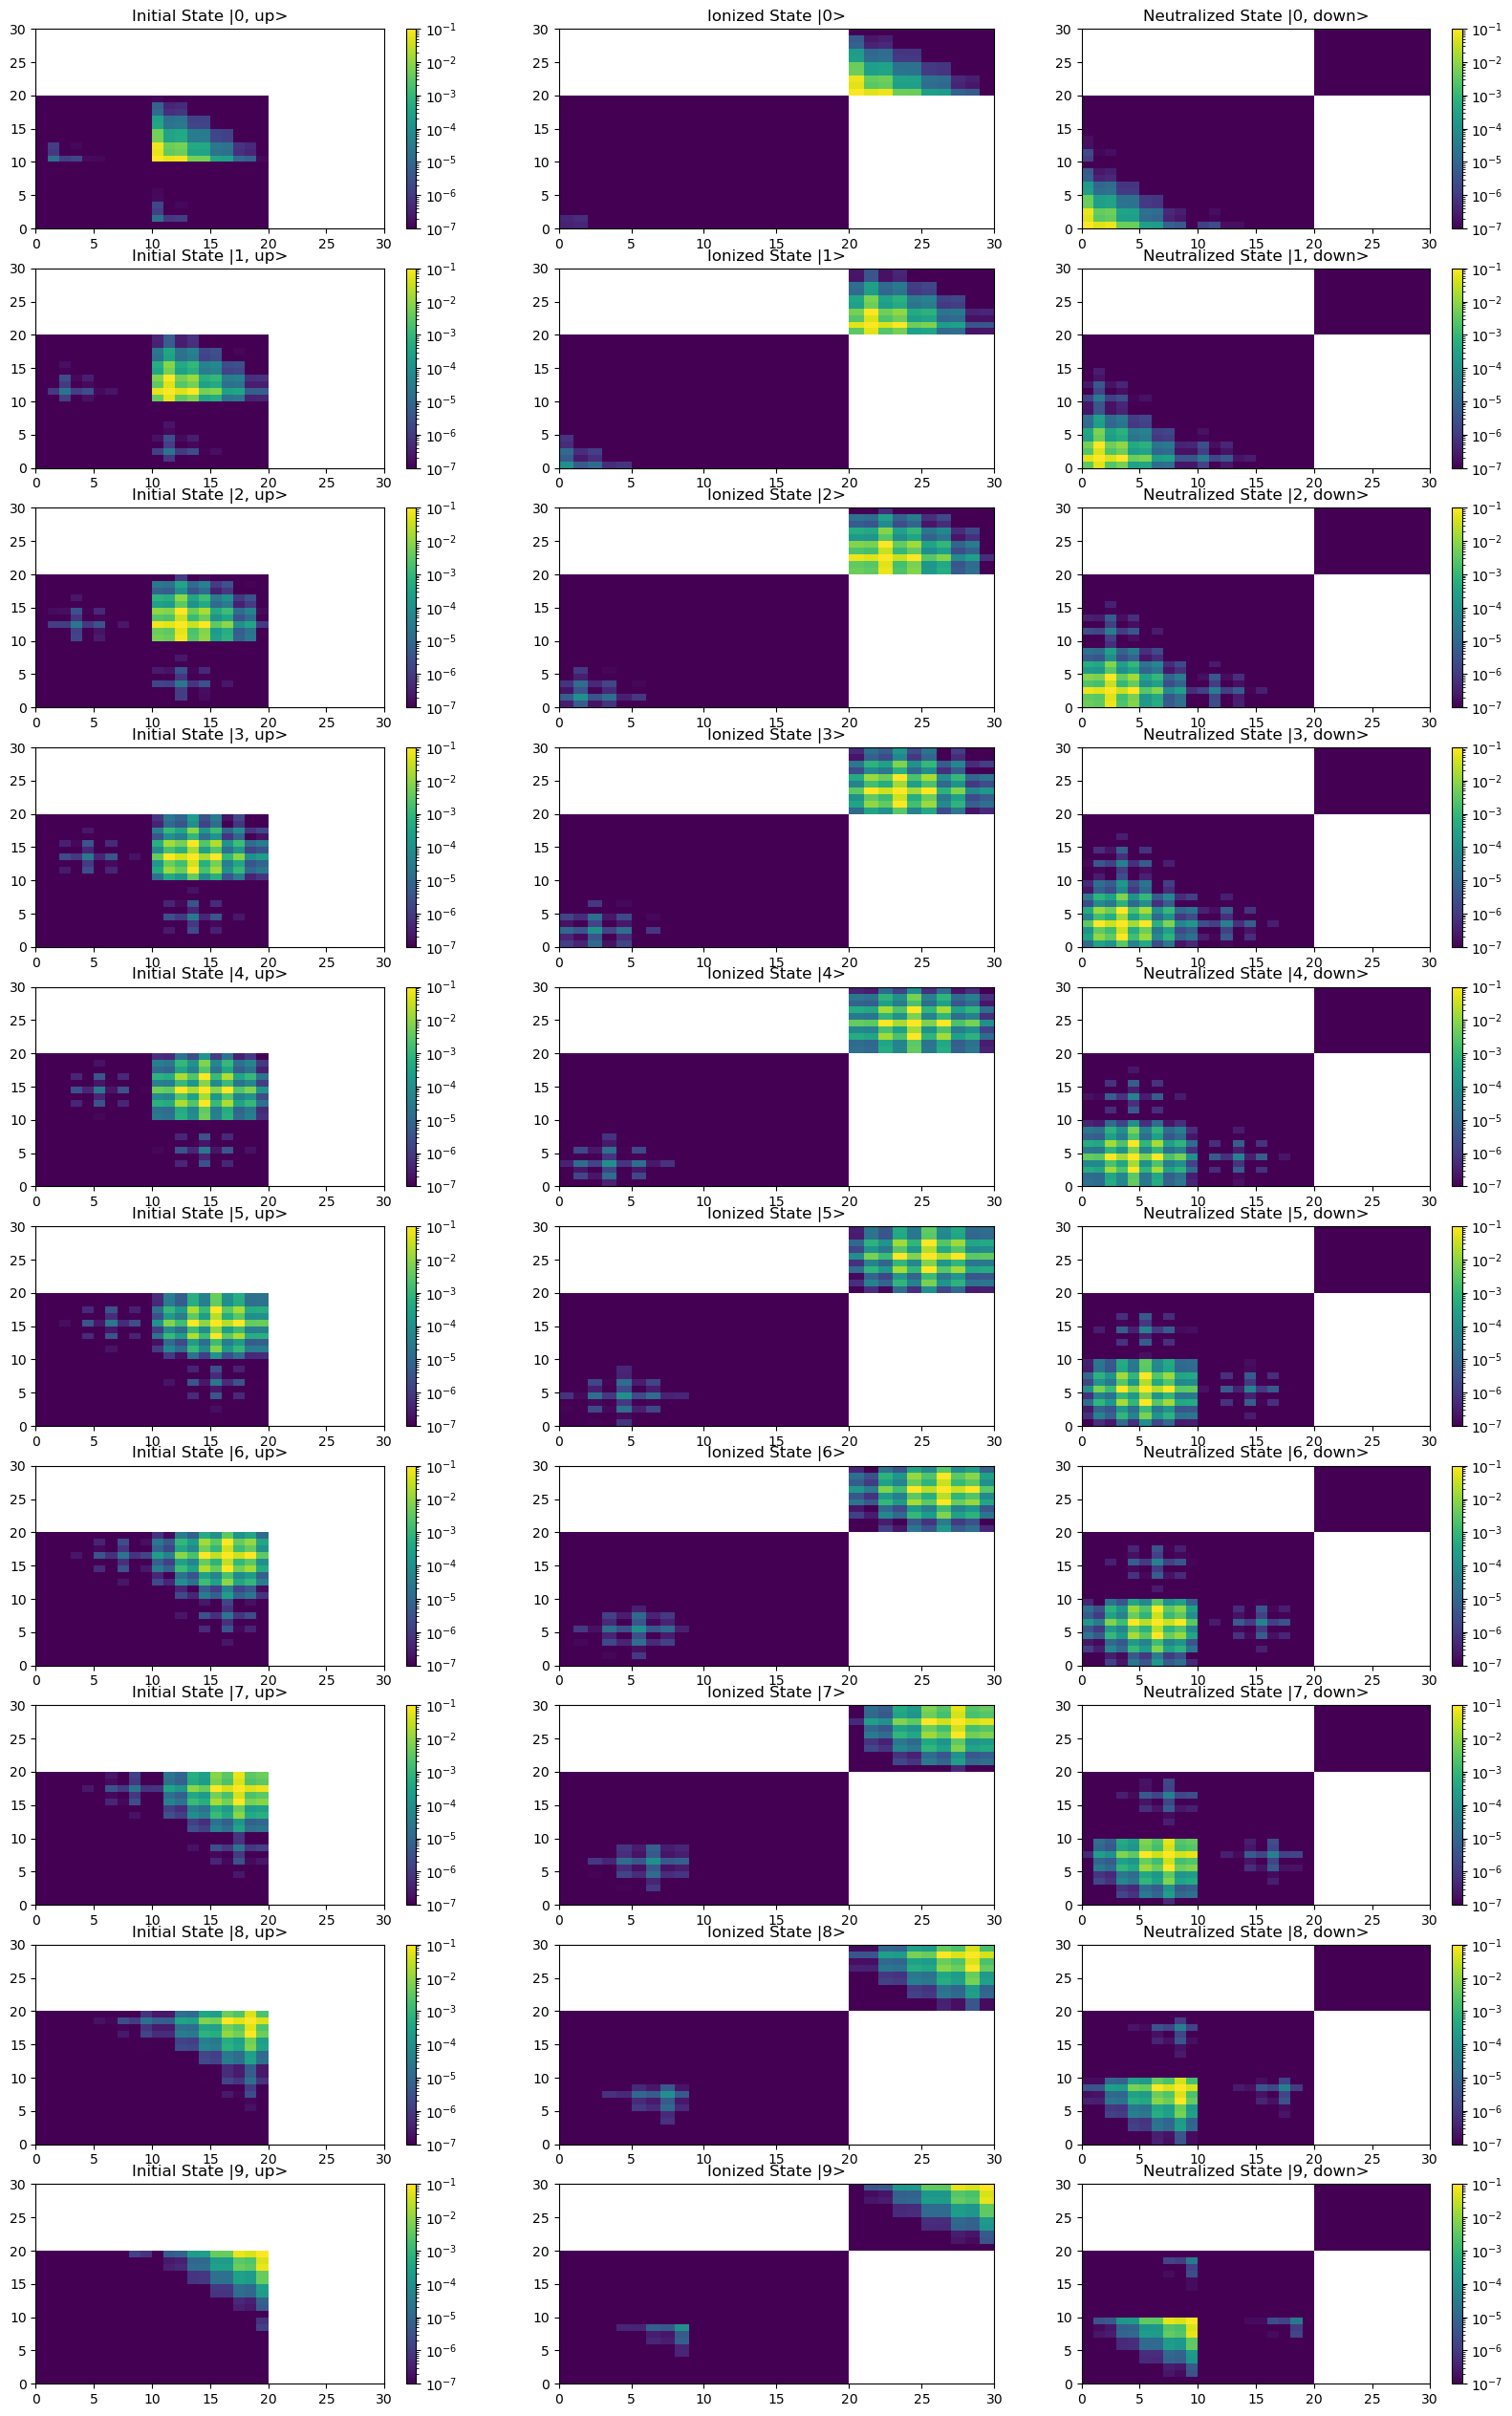

In [26]:
# Plotting the results
fig, ax = plt.subplots(d, 3, figsize=(20, 32))
for i in range(d):
    # Initial state
    rho_0 = qt.ket2dm(qt.Qobj(eigenstate_full_matrix[d + i]))

    ax[i, 0].pcolormesh(np.abs(rho_0.full()), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 0].set_title(f"Initial State |{i}, up>")
    # Ionized state
    pcm1 = ax[i, 1].pcolormesh(np.abs(measured_states[i]), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 1].set_title(f"Ionized State |{i}>")
    plt.colorbar(pcm1, ax=ax[i, 0])

    # Neutralized state
    pcm3 = ax[i, 2].pcolormesh(np.abs(neutralized_states[i]), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 2].set_title(f"Neutralized State |{i}, down>")
    plt.colorbar(pcm3, ax=ax[i, 2])


## transform to eigenbasis

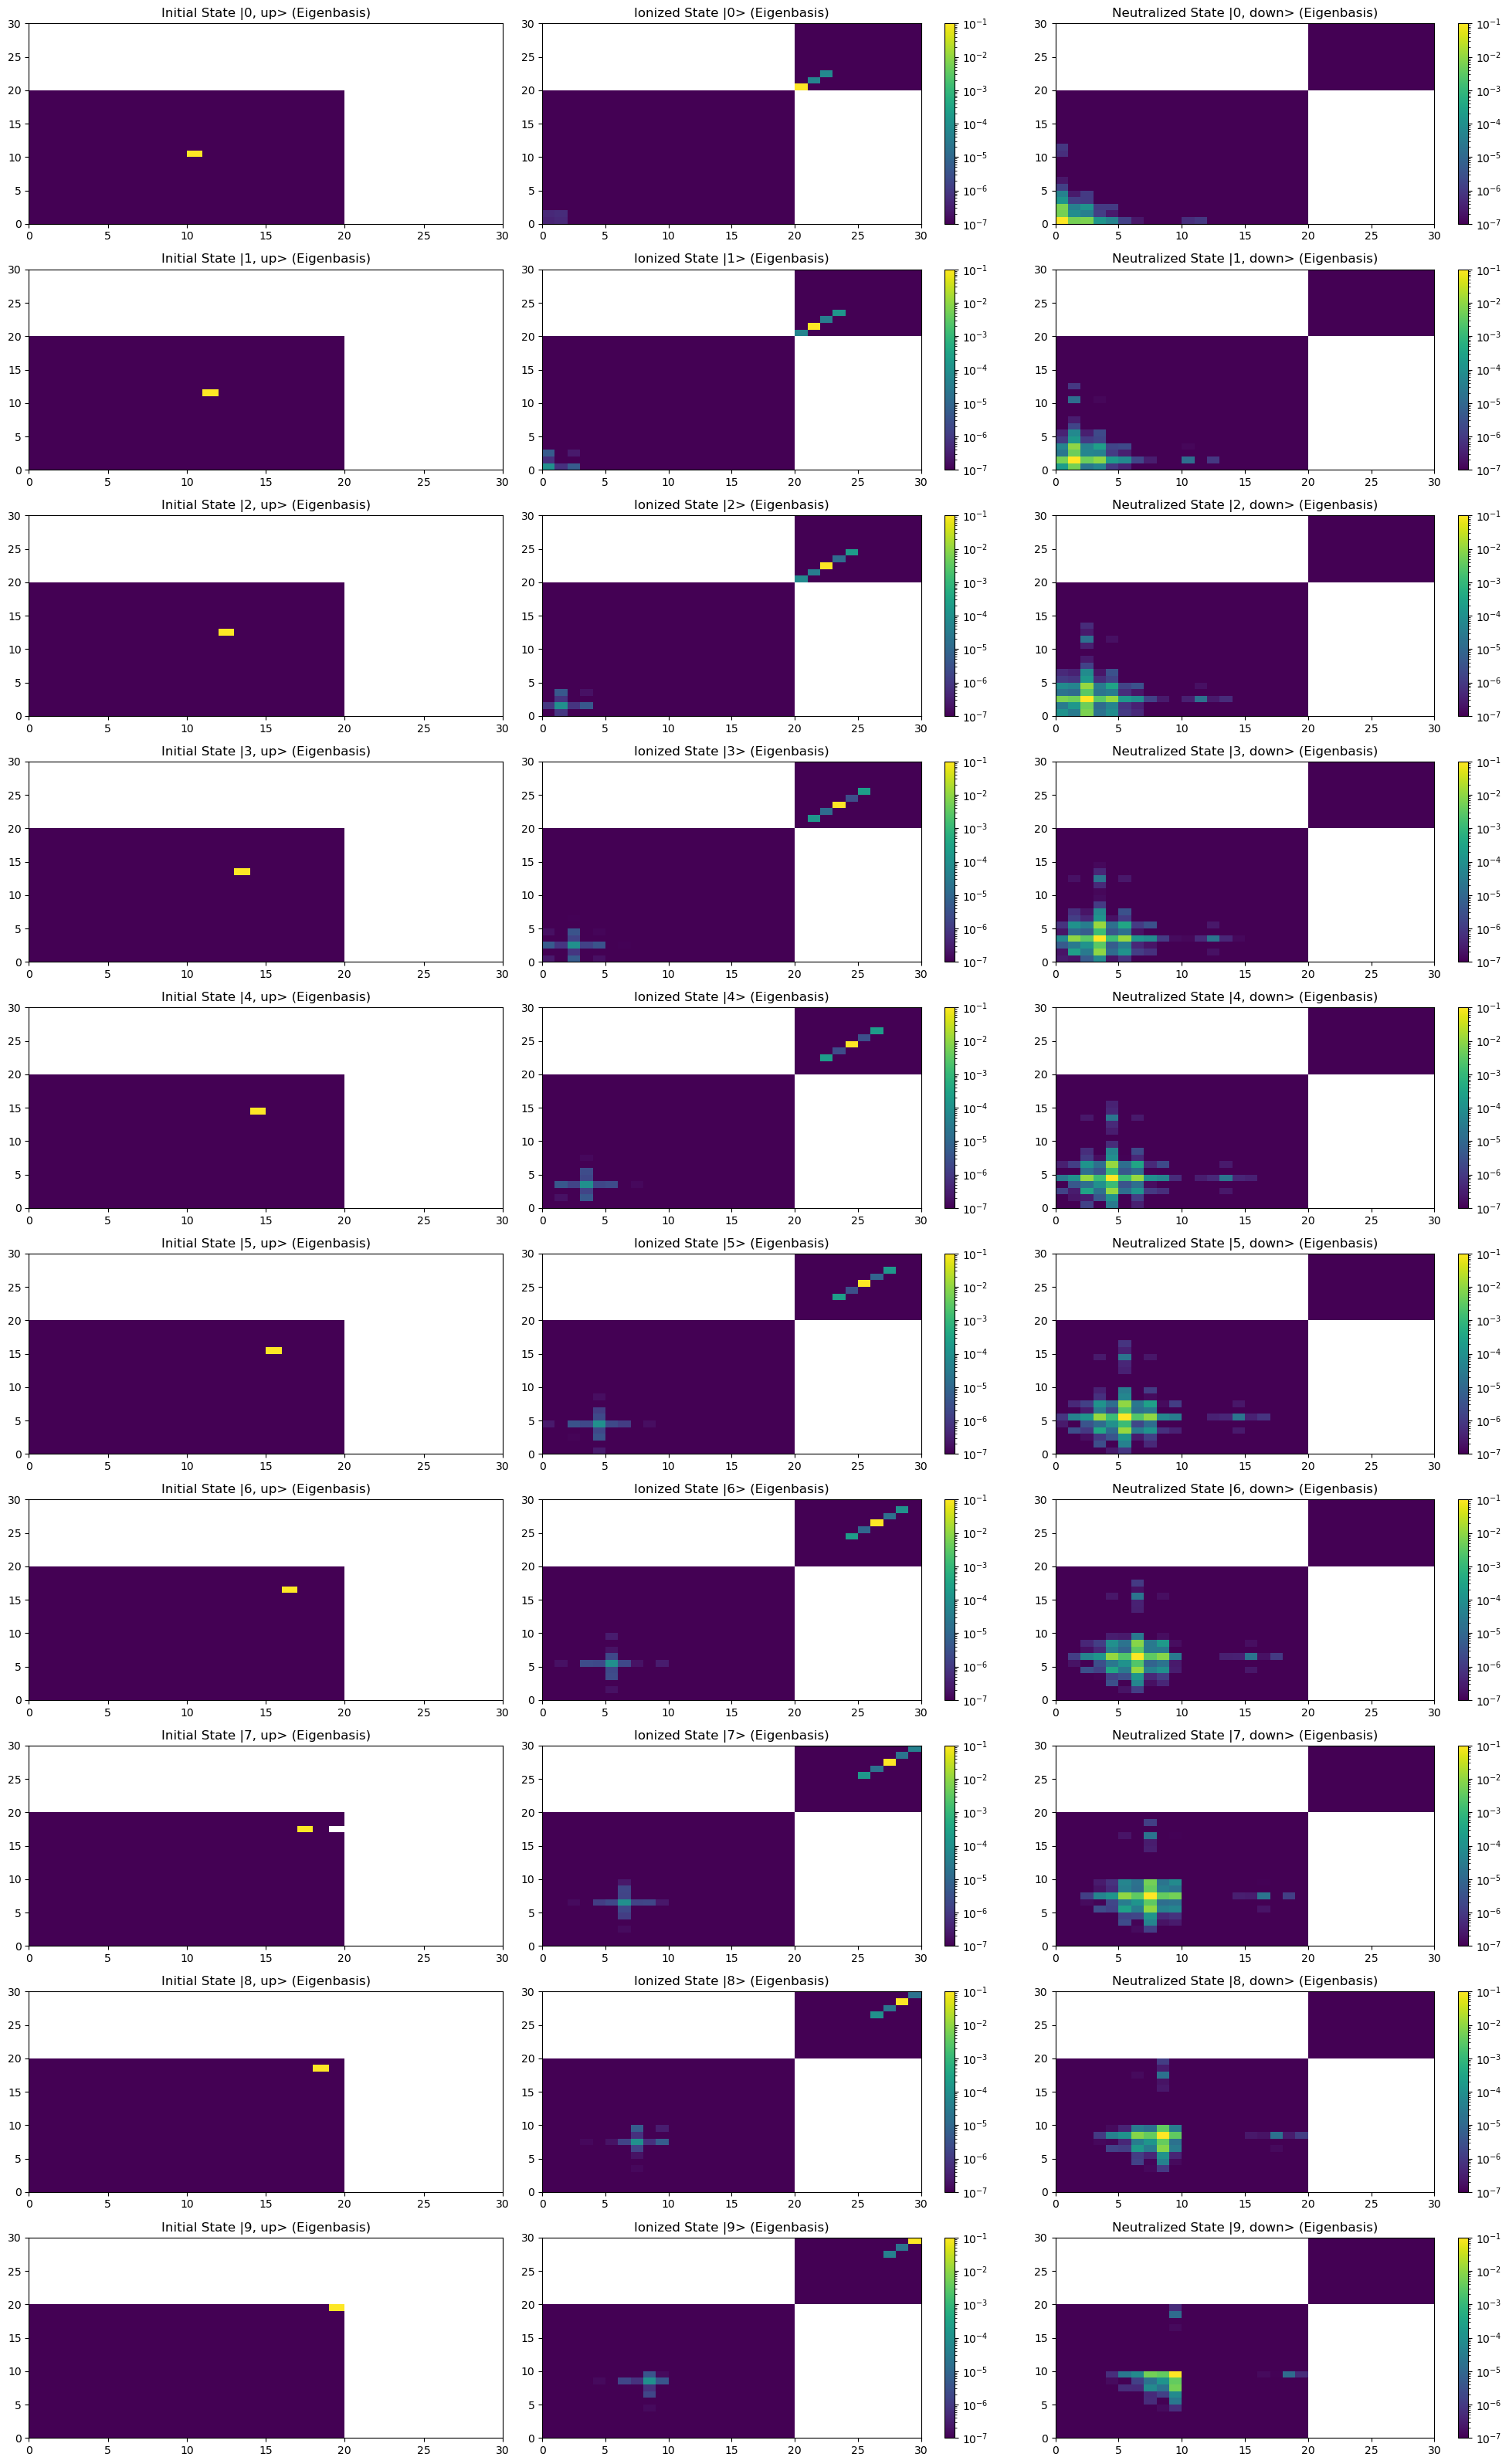

In [27]:
# Plotting the results in the eigenbasis
fig, ax = plt.subplots(d, 3, figsize=(20, 32))
for i in range(d):
    # Initial state
    rho_0 = qt.ket2dm(qt.Qobj(eigenstate_full_matrix[d + i]))
    rho_0_eigenbasis = transform_to_eigenbasis(rho_0.full(), eigenstate_full_matrix)
    ax[i, 0].pcolormesh(np.abs(rho_0_eigenbasis), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 0].set_title(f"Initial State |{i}, up> (Eigenbasis)")

    # Ionized state

    pcm1 = ax[i, 1].pcolormesh(np.abs(measured_states_eigenbasis[i]), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 1].set_title(f"Ionized State |{i}> (Eigenbasis)")
    plt.colorbar(pcm1, ax=ax[i, 1])

    # Neutralized state
    pcm3 = ax[i, 2].pcolormesh(np.abs(neutralized_states_eigenbasis[i]), norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")
    ax[i, 2].set_title(f"Neutralized State |{i}, down> (Eigenbasis)")
    plt.colorbar(pcm3, ax=ax[i, 2])

plt.tight_layout()
plt.show()

In [28]:
ionization_matrix = np.zeros((d, d))
for i in range(d):
    ionization_matrix[i] = np.diag(neutralized_states_eigenbasis[i])[0:d] + np.diag(neutralized_states_eigenbasis[i])[d:2*d]

C:\Users\z5380600\AppData\Local\Temp\ipykernel_8596\49173539.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  ionization_matrix[i] = np.diag(neutralized_states_eigenbasis[i])[0:d] + np.diag(neutralized_states_eigenbasis[i])[d:2*d]


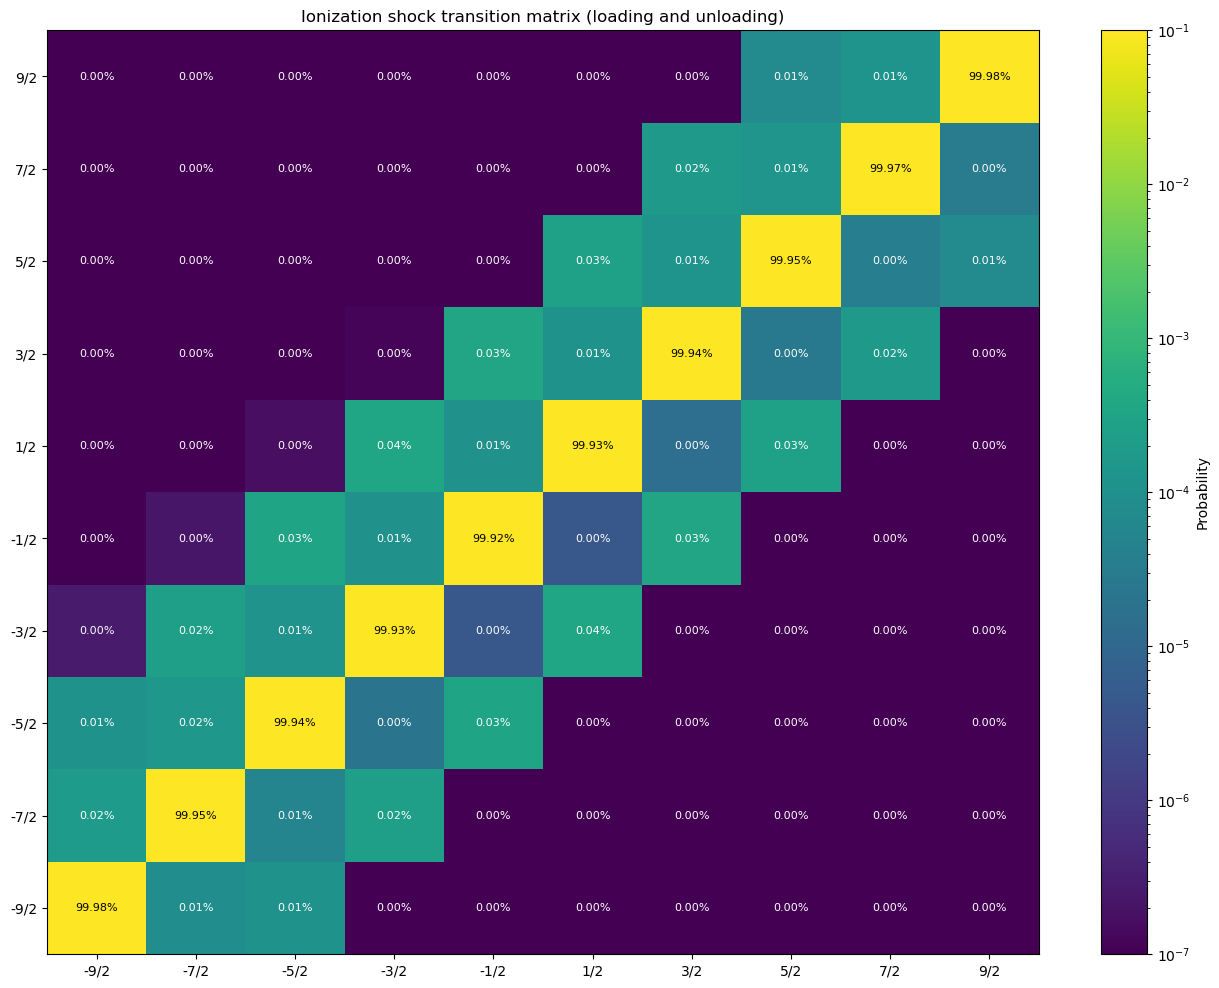

In [29]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
Z = np.abs(ionization_matrix)
X, Y = np.arange(d), np.arange(d)
# Plot with pcolormesh using LogNorm
Z[Z==0]=1e-7

# Convert to percentage
Z_percent = Z * 100  
pcm = plt.pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-1), cmap="viridis")

nucleus_labels = ["-9/2", "-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2", "9/2"]

ax.set_xticks(np.arange(d))
ax.set_yticks(np.arange(d))
ax.set_xticklabels([nucleus_labels[k%d] for k in range(d)])
ax.set_yticklabels([nucleus_labels[k%d] for k in range(d)])

# Annotate with percentages
for i in range(d):
    for j in range(d):
        color = 'black' if i == j else 'white'  # Diagonal elements in black
        ax.text(j, i, f"{Z_percent[i, j]:.2f}%", 
                ha='center', va='center', fontsize=8, color=color)

ax.set_title('Ionization shock transition matrix (loading and unloading)')

plt.colorbar(label='Probability')

In [ ]:
np.save(r'sims_data/ionization_matrix_ge.npy', ionization_matrix)

How many tunnel events are there per 'line' in the ESR measurement?

In [38]:
from scipy.linalg import fractional_matrix_power

In [39]:
n_tunnel = 10
T_est = fractional_matrix_power(ionization_matrix, n_tunnel)

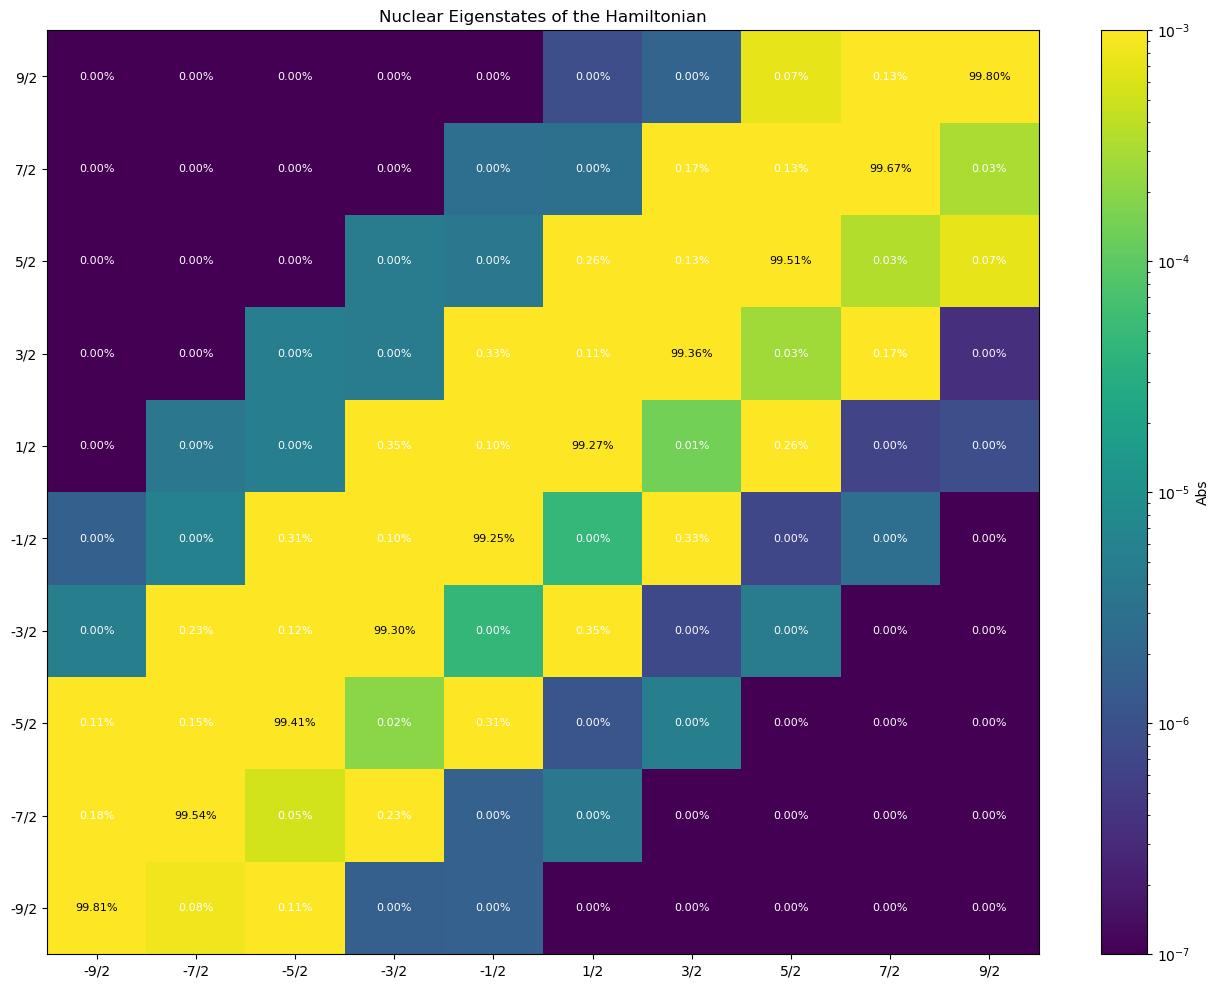

In [40]:
fig, ax = plt.subplots(1,1, figsize=(16,12))
Z = np.abs(T_est)
X, Y = np.arange(d), np.arange(d)
# Plot with pcolormesh using LogNorm
Z[Z==0]=1e-7

# Convert to percentage
Z_percent = Z * 100  
pcm = plt.pcolormesh(X, Y, Z, norm=mcolors.LogNorm(vmin=1e-7, vmax=1e-3), cmap="viridis")

nucleus_labels = ["-9/2", "-7/2", "-5/2", "-3/2", "-1/2", "1/2", "3/2", "5/2", "7/2", "9/2"]

ax.set_xticks(np.arange(d))
ax.set_yticks(np.arange(d))
ax.set_xticklabels(nucleus_labels)
ax.set_yticklabels(nucleus_labels)

# Annotate with percentages
for i in range(d):
    for j in range(d):
        color = 'black' if i == j else 'white'  # Diagonal elements in black
        ax.text(j, i, f"{Z_percent[i, j]:.2f}%", 
                ha='center', va='center', fontsize=8, color=color)

ax.set_title('Nuclear Eigenstates of the Hamiltonian')

plt.colorbar(label='Abs')